![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz


In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

Por medio de la variable Season se puede identificar que el alquiler de bicicletas está altamente relacionado con la temporada del año, especialmente con las condiciones climáticas para los usuarios. Esto se observa porque en temporadas como Fall y Summer, donde las condiciones climáticas son más favorables, se presenta un mayor número de alquileres de bicicletas. Por el contrario, en temporadas como Winter y Spring, las condiciones climáticas afectan el uso de bicicletas, lo que se refleja en una menor cantidad de alquileres registrados. Esto indica que el clima es un factor importante en el comportamiento de los usuarios del sistema de aquiler bicicletas.

In [5]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

Por medio de la variable hour también se logra identificar una alta relación con la hora en la que se alquilan las bicicletas. A partir de esta variable se observa que en horas de la madrugada la cantidad de alquiler de bicicletas es considerablemente menor que en horas de la mañana y la tarde. Esto permite inferir que en la mañana y en la tarde el alquiler de bicicletas puede estar altamente relacionado con el uso de este medio de transporte para actividades diarias, como ir a estudiar o trabajar.

Adicionalmente, se identifica que en horas de la noche vuelve a disminuir el alquiler de bicicletas; sin embargo, este sigue siendo mayor que en horas de la madrugada. Esto permite inferir que las jornadas de los usuarios pueden variar de acuerdo con el tipo de trabajo o estudio que realizan, ya que algunas personas pueden movilizarse en horarios diferentes a los tradicionales.

Para concluir, ambas variables se encuentran altamente relacionadas con el alquiler de bicicletas, y se confirma que influyen de manera considerable en la decisión de alquilar una bicicleta del sistema. Sin embargo, no se puede descartar la relación de variables adicionales que también puedan impactar la decisión de rentar o no una bicicleta, como las condiciones climáticas, la temperatura, la humedad o si es un día laboral o festivo.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

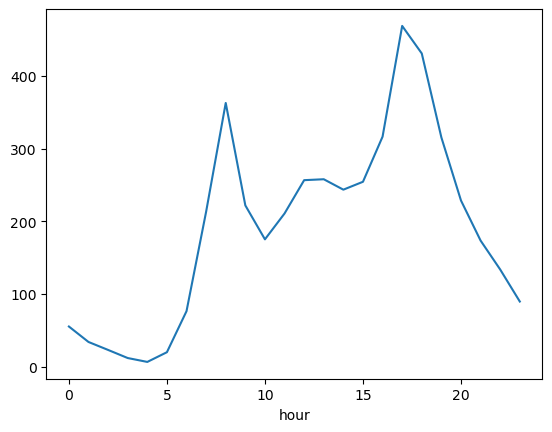

In [6]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

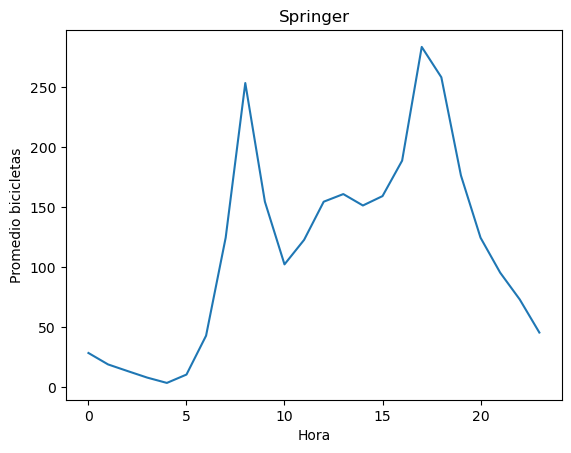

In [13]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
# Filtrar por Springer
season1 = bikes[bikes['season'] == 1]

# Promedio de bicicletas por hora
season1Hour = season1.groupby('hour')['total'].mean()

# Gráfica
season1Hour.plot()

plt.title('Springer')
plt.xlabel('Hora')
plt.ylabel('Promedio bicicletas')
plt.show()

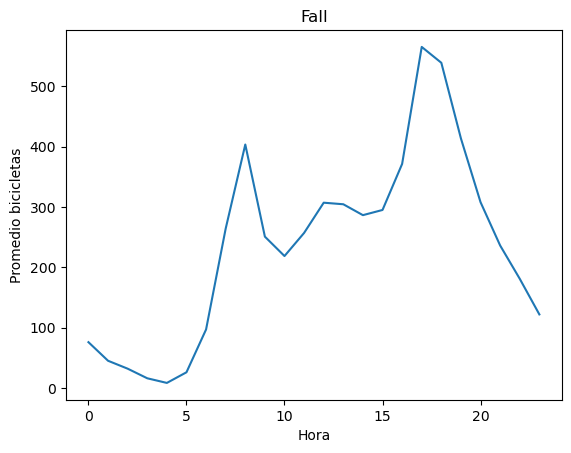

In [12]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos
# Filtrar por Fall 
season3 = bikes[bikes['season'] == 3]

# Promedio de bicicletas por hora
season3_hour = season3.groupby('hour')['total'].mean()

# Gráfica
season3_hour.plot()

plt.title('Fall')
plt.xlabel('Hora')
plt.ylabel('Promedio bicicletas')
plt.show()

Por medio de ambos gráficos se puede observar que ambas temporadas (Spring y Fall) muestran un comportamiento similar en cuanto a la hora del día en la que se rentan las bicicletas. Se confirma que en la madrugada el número de bicicletas rentadas es bajo, mientras que en la mañana y en la tarde se presentan los picos de mayor demanda. En la noche el número de alquileres vuelve a disminuir, aunque sigue siendo mayor que en la madrugada.

Adicionalmente, se observa que la temporada afecta considerablemente la demanda de bicicletas, ya que, a pesar de mantener un comportamiento similar durante el día, en la temporada Fall se presenta una mayor cantidad de bicicletas rentadas en comparación con Spring. Esto confirma que tanto la hora del día como la temporada influyen en el uso del sistema de alquiler de bicicletas.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [14]:
# Celda 3
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Crear variables dummy para la variable categórica season
seasonDummies = pd.get_dummies(bikes['season'], prefix='season', drop_first=True)

# Crear matriz de variables predictoras
X = pd.concat([seasonDummies, bikes[['hour']]], axis=1)

# Variable objetivo
y = bikes['total']

# Train-test split
XTrain, XTest, yTrain, yTest = train_test_split(X, y, random_state=1)

# Modelo de regresión lineal
linearReg = LinearRegression()

# Entrenar modelo
linearReg.fit(XTrain, yTrain)

# Coeficientes del modelo
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': linearReg.coef_
})

coeficientes


,Variable,Coeficiente
0,season_2,93.830184
1,season_3,118.740651
2,season_4,81.148483
3,hour,10.628063


Con respecto a la interpretación de los coeficientes usando regresión lineal, para la variable season utilizamos variables dummy al ser una variable categórica. En este caso, los coeficientes representan la diferencia en el número de bicicletas alquiladas con respecto a la temporada base, que corresponde a season 1 – Spring. A partir de esto, se puede identificar que la temporada 3 presenta el mayor número de alquileres en comparación con la base, seguida de la temporada 2 y la temporada 4.

En el caso de la variable hour, el coeficiente permite inferir que por cada hora adicional del día, el número de bicicletas alquiladas aumenta en promedio aproximadamente 10 bicicletas, manteniendo la temporada constante.

**Limitaciones Modelo Regresión Lineal**

• La relación entre la variable hour y la cantidad de alquileres de bicicletas no es lineal, ya que durante el día se presentan picos de demanda. Esto no permite un adecuado modelamiento mediante regresión lineal.

• El modelo puede asumir que el efecto de la hora sobre la cantidad de alquileres es constante durante todo el día, lo cual no es correcto, ya que existen horas con mayor demanda que otras.

• Finalmente, el modelo no está considerando otras posibles interacciones que puedan ser relevantes entre las temporadas y las horas del día, ni variables como el clima, la temperatura y la humedad, que también pueden estar relacionadas con la demanda del alquiler de bicicletas.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [24]:
# Celda 4
bestHour = None
bestMSE = float('inf')

for h in range(0, 24):
    
    left = bikes[bikes['hour'] <= h]
    right = bikes[bikes['hour'] > h]
    
    if len(left) > 0 and len(right) > 0:
        
        mseLeft = np.mean((left['total'] - left['total'].mean())**2)
        mseRight = np.mean((right['total'] - right['total'].mean())**2)
        
        error = mseLeft + mseRight
        
        if error < bestMSE:
            bestMSE = error
            bestHour = h

print("Mejor hour split:", bestHour)

# Dividir dataset
nodeLeft = bikes[bikes['hour'] <= bestHour]
nodeRight = bikes[bikes['hour'] > bestHour]


Mejor hour split: 5


In [ ]:

# Buscar el mejor split para Season

bestSeasonLeft = None
bestMSELeft = float('inf')

for s in bikes['season'].unique():
    
    left = nodeLeft[nodeLeft['season'] == s]
    right = nodeLeft[nodeLeft['season'] != s]
    
    if len(left) > 0 and len(right) > 0:
        
        mseLeft = np.mean((left['total'] - left['total'].mean())**2)
        mseRight = np.mean((right['total'] - right['total'].mean())**2)
        
        error = mseLeft + mseRight
        
        if error < bestMSELeft:
            bestMSELeft = error
            bestSeasonLeft = s

print("Mejor season split izquierda: ", bestSeasonLeft)

node2Left = nodeLeft[nodeLeft['season'] == bestSeasonLeft]
node2Right = nodeLeft[nodeLeft['season'] != bestSeasonLeft]

Mejor season split izquierda:  1


In [26]:
# Split en hour para nodo derecho

bestHourRight = None
bestMSERight = float('inf')

for h in range(0, 24):
    
    left = nodeRight[nodeRight['hour'] <= h]
    right = nodeRight[nodeRight['hour'] > h]
    
    if len(left) > 0 and len(right) > 0:
        
        mseLeft = np.mean((left['total'] - left['total'].mean())**2)
        mseRight = np.mean((right['total'] - right['total'].mean())**2)
        
        error = mseLeft + mseRight
        
        if error < bestMSERight:
            bestMSERight = error
            bestHourRight = h

print("Mejor hour split derecho: ", bestHourRight)

node3Left = nodeRight[nodeRight['hour'] <= bestHourRight]
node3Right = nodeRight[nodeRight['hour'] > bestHourRight]

Mejor hour split derecho:  22


In [ ]:
# predicciones hojas (mínimo 6 hojas)

print("Hoja 1:", node2Left['total'].mean())
print("Hoja 2:", node2Right['total'].mean())
print("Hoja 3:", node3Left['total'].mean())
print("Hoja 4:", node3Right['total'].mean())
print("Hoja 5:", nodeLeft['total'].mean())
print("Hoja 6:", nodeRight['total'].mean())

Hoja 1: 13.9765625
Hoja 2: 28.684931506849313
Hoja 3: 255.23922024270593
Hoja 4: 89.50877192982456
Hoja 5: 25.177719821162444
Hoja 6: 246.025237746891


Para la construcción del árbol de decisión manual se iteró utilizando las variables hour y season, con el objetivo principal de identificar los puntos de corte que minimizan el MSE. En cada iteración fue importante evaluar las diferentes posibles divisiones de los datos, con el fin de seleccionar aquella que generara el menor error dentro de cada nodo.

Posteriormente, se continuó dividiendo los nodos hasta obtener al menos seis nodos finales. Para cada nodo final, la predicción corresponde al promedio de la variable total de las observaciones que pertenecen a ese nodo, permitiendo así dividir los datos en grupos cada vez más homogéneos con respecto a la variable objetivo.


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

-13105.88063822368
114.43423491060207


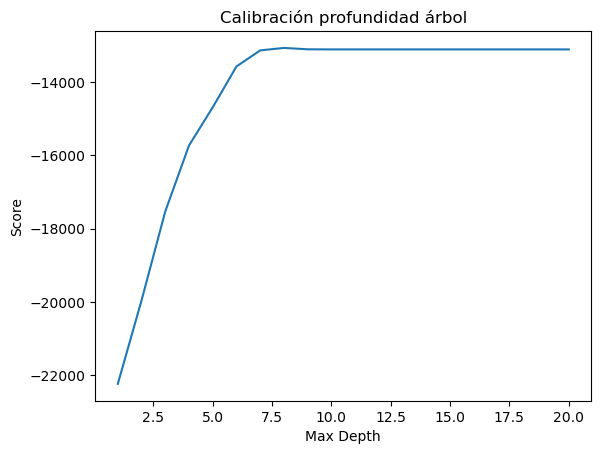

MSE: 14752.618644492284
RMSE: 121.46035832522595


In [28]:
# Celda 5

from sklearn.metrics import mean_squared_error

# Variables predictoras
X = bikes[['season','hour']]

# Variable objetivo
y = bikes['total']

# Train-Test Split
XTrain, XTest, yTrain, yTest = train_test_split(X, y, random_state=1)

# Entrenamiento
tree = DecisionTreeRegressor(random_state=1)
tree.fit(XTrain, yTrain)

# Evaluar modelo (MSE con CV)

scores = cross_val_score(tree, XTrain, yTrain, cv=5, scoring='neg_mean_squared_error')
print(np.mean(scores))

# RMSE

rmse = np.sqrt(-scores)
print(rmse.mean())

# Calibrar max_depth

depthRange = range(1, 21)
scores = []

for depth in depthRange:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=1)
    score = cross_val_score(tree, XTrain, yTrain, cv=5, scoring='neg_mean_squared_error')
    scores.append(np.mean(score))

plt.plot(depthRange, scores)
plt.xlabel('Max Depth')
plt.ylabel('Score')
plt.title('Calibración profundidad árbol')
plt.show()

# Entrenar modelo final
tree = DecisionTreeRegressor(max_depth=5, random_state=1)
tree.fit(XTrain, yTrain)

# Evaluar en test

pred = tree.predict(XTest)
mse = mean_squared_error(yTest, pred)

print("MSE:", mse)
print("RMSE:", np.sqrt(mse))

Se entrenó un árbol de decisión usando la librería sklearn, season y hour como variables predictoras y como variable objetivo la cantidad de bicicletas alquiladas (total). Los datos se dividieron en conjuntos de entrenamiento y de prueba para evaluar el desempeño del modelo.


Posteriormente, se calibró el parámetro max_depth para determinar la profundidad óptima del árbol y evitar un sobreajuste. A partir de la gráfica de calibración, se logra identificar que el desempeño del modelo mejora a medida que aumenta la profundidad del árbol hasta aproximadamente una profundidad de 8 niveles, luego ya el modelo presenta estabilidad. Por esta razón, se selecciona una profundidad cercana a este valor como la más adecuada para el modelo.


Finalmente, se evaluó el modelo utilizando el MSE y RMSE, obteniendo un RMSE cercano a 121 bicicletas, lo que indica el error promedio de predicción del modelo.
Al comparar este modelo con la regresión lineal, se observa que el árbol de decisión presenta un mejor desempeño, ya que permite modelar relaciones no lineales entre las variables, especialmente con la variable hour, donde existen picos de demanda en ciertas horas del día.


## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [29]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [31]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [32]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

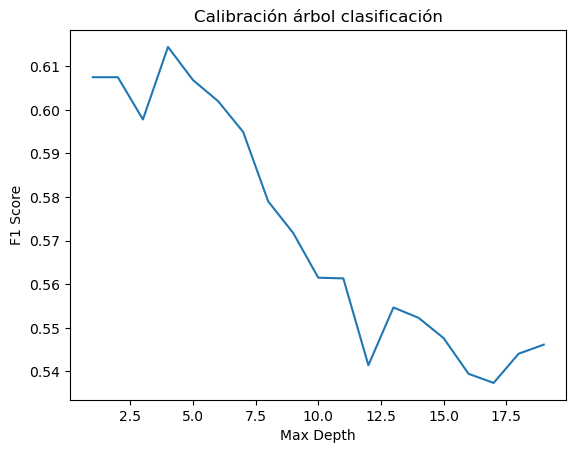

In [ ]:
# Celda 6

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Arbol de decision (clasificación)

depth_range = range(1, 20)
scores = []


for depth in depth_range:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=1) # Calibración del parametro max_depth
    score = cross_val_score(tree, X_train, y_train, cv=5, scoring='f1')
    scores.append(score.mean())

import matplotlib.pyplot as plt
plt.plot(depth_range, scores)
plt.xlabel('Max Depth')
plt.ylabel('F1-Score')
plt.title('Calibración árbol clasificación')
plt.show()

In [ ]:
# Entrenar árbol final
tree = DecisionTreeClassifier(max_depth=5, random_state=1)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

# Accuracy y F1-score
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy Tree:", accuracy_score(y_test, y_pred_tree))
print("F1-Score Tree:", f1_score(y_test, y_pred_tree))

Accuracy Tree: 0.6373333333333333
F1 Tree: 0.6616915422885572


In [ ]:
# Regresión logística

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_log = logreg.predict(X_test)

print("Accuracy Logistic:", accuracy_score(y_test, y_pred_log))
print("F1-Score Logistic:", f1_score(y_test, y_pred_log))

Accuracy Logistic: 0.6193333333333333
F1 Logistic: 0.6053904630269523


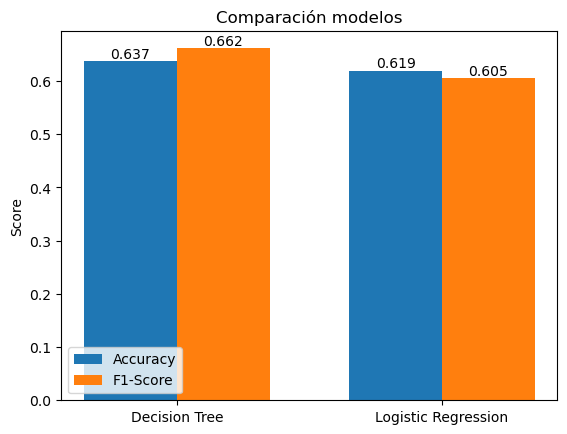

In [40]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

accuracy_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

models = ['Decision Tree', 'Logistic Regression']
accuracy = [accuracy_tree, accuracy_log]
f1 = [f1_tree, f1_log]

x = np.arange(len(models))
width = 0.35

plt.figure()

bars1 = plt.bar(x - width/2, accuracy, width, label='Accuracy')
bars2 = plt.bar(x + width/2, f1, width, label='F1-Score')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Comparación modelos')
plt.legend()

# Agregar labels de barras
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.3f}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.3f}', ha='center', va='bottom')

plt.show()

Para el modelo de árbol de decisión se calibró el parámetro max_depth, el cual determina la profundidad del árbol. Adicionalmente, se probaron diferentes valores de profundidad, evaluando el desempeño del modelo en cada uno utilizando validación cruzada y la métrica de F1-score, con el fin de seleccionar el valor que mejor desempeño presentara y evitar problemas de overfitting.

Al comparar ambos modelos, se observa que el árbol de decisión captura relaciones no lineales entre las variables, mientras que la regresión logística asume relaciones lineales. De acuerdo con los resultados obtenidos, el árbol de decisión presentó un Accuracy de **0.637** y un F1-Score de **0.662**, mientras que la regresión logística presentó un Accuracy de **0.619** y un F1-Score de **0.605**.

Con base en estos resultados, se puede observar que el modelo de árbol de decisión presenta un mejor desempeño que la regresión logística, especialmente en la métrica F1-Score, lo cual indica que el árbol logra un mejor balance entre precisión y recall en la clasificación de noticias populares.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

Para la construcción del ensamble se utilizaron 300 modelos, que se entrearon sobre muestras bootstrap del conjunto de entrenimiento. Cada modelo genero predicciones sobre el conjunto de prueba, y posteriormente se realizo la votación mayoritaria sobre las 300 predicciones. la predicción final se obtuvo tomando la clase que presento mayoria de votos entre los modelos.

Finalmente se evaluo el modelo por medio de accrurracy y F1-score. presentando un mejor desempeño en el ensamble que en los modelos individuales, lo cual permite concluir que la combinación de modelos mejora en gran medida la preidcción y así mismo reducir la varianza del modelo.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [43]:
# Celda 8

from sklearn.utils import resample
predictions = []

# 100 árboles max_depth
for i in range(100):
    X_boot, y_boot = resample(X_train, y_train)
    modelo = DecisionTreeClassifier(max_depth=5)
    modelo.fit(X_boot, y_boot)
    predictions.append(modelo.predict(X_test))

# 100 árboles min_samples_leaf
for i in range(100):
    X_boot, y_boot = resample(X_train, y_train)
    modelo = DecisionTreeClassifier(min_samples_leaf=5)
    modelo.fit(X_boot, y_boot)
    predictions.append(modelo.predict(X_test))

# 100 regresiones logísticas
for i in range(100):
    X_boot, y_boot = resample(X_train, y_train)
    modelo = LogisticRegression(max_iter=1000)
    modelo.fit(X_boot, y_boot)
    predictions.append(modelo.predict(X_test))

# Aplicar pesos

predictions = np.array(predictions)

predFinalPonderado = []

for i in range(predictions.shape[1]):
    
    votos = predictions[:, i]
    
    # Pesos
    votos_ponderados = (
        np.sum(votos[:100]) * 0.4 +
        np.sum(votos[100:200]) * 0.4 +
        np.sum(votos[200:300]) * 0.2
    )
    
    if votos_ponderados >= (0.5 * (100)):
        predFinalPonderado.append(1)
    else:
        predFinalPonderado.append(0)

predFinalPonderado = np.array(predFinalPonderado)

print("Accuracy Ponderado:", accuracy_score(y_test, predFinalPonderado))
print("F1-Score Ponderado:", f1_score(y_test, predFinalPonderado, average='weighted'))

Accuracy Ponderado: 0.6513333333333333
F1-Score Ponderado: 0.6510522144362503


Para la votación ponderada, se hizo uso de los mismo 300 modelos generados anteriormente mediante muestras bootstrap. Sin embargo, a diferencia de votación mayoritaria, en este caso se asginaron diferentes pesos a los modelos segun el tipo. Asignando mayor peso a los de arboles de decisión y menor peso a los de regresión logistica.

Adicionalmente, se calcularon los votos ponderados por observación y así determinar la clase final, claramente dependiendo si la suma ponderada superaba el umbral establecido. Finalmente, se evaluo el desempeño del ensable usando Accurracy y F1-score.

En el que se identifico que la votación ponderada permite apotar mayor importancia a los modelos que se puedan considerar como robustos. Lo anterior, mejorando el desempeño del ensable en comparación con la votación mayoritaria.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

Para concluir, al comparar los resultados obtenidos mediante votación mayoritaria y votación ponderada, se observa que ambos métodos de ensamblaje mejoran en gran medida el desempeño de los modelos individuales. Esto se debe a que ambos métodos de ensamblaje combinan múltiples modelos y reducen la varianza del modelo final.

La votación mayoritaria asigna el mismo peso a todos los modelos, mientras que la votación ponderada permite asignar mayor importancia a ciertos modelos, como los árboles de decisión, que suelen capturar mejores relaciones no lineales entre las variables.

En general, los métodos de ensamblaje permiten obtener modelos más robustos y con mejor capacidad de generalización, ya que combinan la información de múltiples modelos en lugar de depender de un solo modelo.
